In [1]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

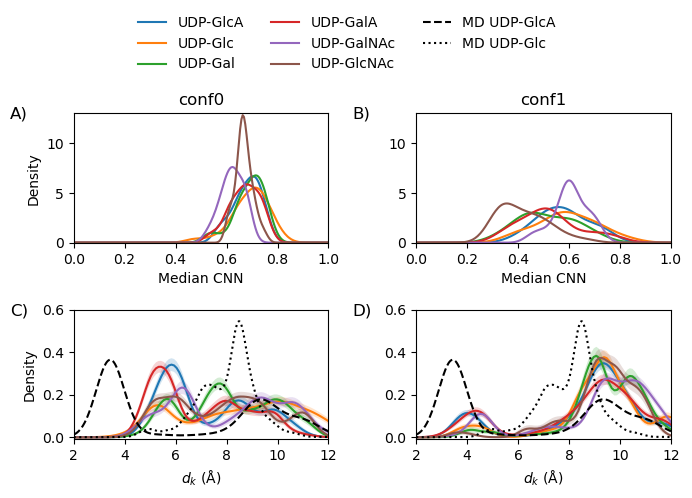

In [2]:
datasets_kde_wt1 = [
    ("UDP-GlcA",  "bootstrap_kde_distribution_glcA.csv"),
    ("UDP-Glc",   "bootstrap_kde_distribution_glc.csv"),
    ("UDP-Gal",   "bootstrap_kde_distribution_gla.csv"),
    ("UDP-GalA",  "bootstrap_kde_distribution_glaA.csv"),
    ("UDP-GalNAc","bootstrap_kde_distribution_ngla.csv"),
    ("UDP-GlcNAc","bootstrap_kde_distribution_nglu.csv"),
]

datasets_kde_wtb = [
    ("UDP-GlcA",  "bootstrap_kde_distribution_glcA_wtb.csv"),
    ("UDP-Glc",   "bootstrap_kde_distribution_glc_wtb.csv"),
    ("UDP-Gal",   "bootstrap_kde_distribution_gal_wtb.csv"),
    ("UDP-GalA",  "bootstrap_kde_distribution_galA_wtb.csv"),
    ("UDP-GalNAc","bootstrap_kde_distribution_ngal_wtb.csv"),
    ("UDP-GlcNAc","bootstrap_kde_distribution_nglc_wtb.csv"),
]

datasets_cnn_wt1 = [
    ("UDP-GlcA",  "median_cnn_per_replica_UDP-GlcA.csv"),
    ("UDP-Glc",   "median_cnn_per_replica_UDP-Glc.csv"),
    ("UDP-Gal",   "median_cnn_per_replica_UDP-Gal.csv"),
    ("UDP-GalA",  "median_cnn_per_replica_UDP-GalA.csv"),
    ("UDP-GalNAc","median_cnn_per_replica_UDP-GalNAc.csv"),
    ("UDP-GlcNAc","median_cnn_per_replica_UDP-GlcNAc.csv"),
]

datasets_cnn_wtb = [
    ("UDP-GlcA",  "median_cnn_per_replica_UDP-GlcA_WB.csv"),
    ("UDP-Glc",   "median_cnn_per_replica_UDP-Glc_WB.csv"),
    ("UDP-Gal",   "median_cnn_per_replica_UDP-Gal_WB.csv"),
    ("UDP-GalA",  "median_cnn_per_replica_UDP-GalA_WB.csv"),
    ("UDP-GalNAc","median_cnn_per_replica_UDP-GalNAc_WB.csv"),
    ("UDP-GlcNAc","median_cnn_per_replica_UDP-GlcNAc_WB.csv"),
]

datasets_kde_boltz = [
    ("UDP-GlcA",  "bootstrap_kde_glca_boltz.csv"),
    ("UDP-Glc",   "bootstrap_kde_glc_boltz.csv"),
    ("UDP-Gal",   "bootstrap_kde_gal_boltz.csv"),
    ("UDP-GalA",  "bootstrap_kde_gala_boltz.csv"),
    ("UDP-GalNAc","bootstrap_kde_galnac_boltz.csv"),
    ("UDP-GlcNAc","bootstrap_kde_glcnac_boltz.csv"),
]

datasets_kde_af3 = [
    ("UDP-GlcA",  "bootstrap_kde_glca_af3.csv"),
    ("UDP-Glc",   "bootstrap_kde_glc_af3.csv"),
    ("UDP-Gal",   "bootstrap_kde_gal_af3.csv"),
    ("UDP-GalA",  "bootstrap_kde_gala_af3.csv"),
    ("UDP-GalNAc","bootstrap_kde_galnac_af3.csv"),
    ("UDP-GlcNAc","bootstrap_kde_glcnac_af3.csv"),
]



data_md_glcA = np.loadtxt("COLVAR").transpose()
weights_md_glcA = np.loadtxt("weights.txt")
dk_md_glcA = data_md_glcA[2] * 10.0

data_md_glc = np.loadtxt("COLVAR_glu").transpose()
weights_md_glc = np.loadtxt("weights_glu.txt")
dk_md_glc = data_md_glc[2] * 10.0

# Use same KDE setup as above (Scott + factor*0.6)
kde_md_glcA = gaussian_kde(dk_md_glcA, weights=weights_md_glcA)
kde_md_glcA.set_bandwidth(bw_method=kde_md_glcA.factor * 0.6)

kde_md_glc = gaussian_kde(dk_md_glc, weights=weights_md_glc)
kde_md_glc.set_bandwidth(bw_method=kde_md_glc.factor * 0.6)

x_grid_md = np.linspace(2, 12, 500)
y_md_glcA = kde_md_glcA(x_grid_md)
y_md_glc  = kde_md_glc(x_grid_md)




# ======================
# HELPERS
# ======================

def plot_bootstrap_kde(ax, datasets,
                       xlim=(2,12), ylim=(-0.01,0.6),
                       xlabel=r"$d_k$ (Å)", ylabel="Density"):

    for label, filename in datasets:
        df = pd.read_csv(filename)

        x = df["x"].to_numpy()
        mean_kde = df["kde_mean"].to_numpy()
        std_kde  = df["kde_std"].to_numpy()

        ax.plot(x, mean_kde, label=label)
        ax.fill_between(x,
                        mean_kde - std_kde,
                        mean_kde + std_kde,
                        alpha=0.2)

 
    ax.plot(x_grid_md, y_md_glcA, linestyle="--",  linewidth=1.5, label="MD UDP-GlcA", color="black")
    ax.plot(x_grid_md, y_md_glc,  linestyle=":",   linewidth=1.5, label="MD UDP-Glc", color="black")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def plot_cnn_median_kde(ax, datasets,
                        xlim=(0,1),
                        ylim=(-0.01,13),
                        xlabel="Median CNN",
                        ylabel="Density",
                        n_grid=200):

    x_grid = np.linspace(xlim[0], xlim[1], n_grid)

    for label, filename in datasets:
        df = pd.read_csv(filename)
        values = df["cnn_pose_score"].to_numpy()

        kde = gaussian_kde(values)
        y = kde(x_grid)

        ax.plot(x_grid, y, label=label)

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def panel_letter(ax, letter):
    ax.text(-0.25, 1.05, f"{letter})",
            transform=ax.transAxes,
            fontsize=12,
            va="top")

# ======================
# FIGURE 2x2 (5 x 7 inches)
# ======================

fig, axes = plt.subplots(2, 2, figsize=(7, 5))

axes[0,0].set_title("conf0")
axes[0,1].set_title("conf1")
# Top row
plot_cnn_median_kde(axes[0,0], datasets_cnn_wt1)
plot_cnn_median_kde(axes[0,1], datasets_cnn_wtb)
# Bottom row
plot_bootstrap_kde(axes[1,0], datasets_kde_wt1)
plot_bootstrap_kde(axes[1,1], datasets_kde_wtb)


# Panel labels
panel_letter(axes[0,0], "A")
panel_letter(axes[0,1], "B")
panel_letter(axes[1,0], "C")
panel_letter(axes[1,1], "D")

# Remove right y-labels for cleaner layout
axes[0,1].set_ylabel("")
axes[1,1].set_ylabel("")

# Global legend
handles, labels = axes[1,0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.),   # più alto
           ncol=3,
           frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.85])

plt.savefig("Figure_WT1_WTB_2x2.png", dpi=600, bbox_inches="tight")


plt.show()

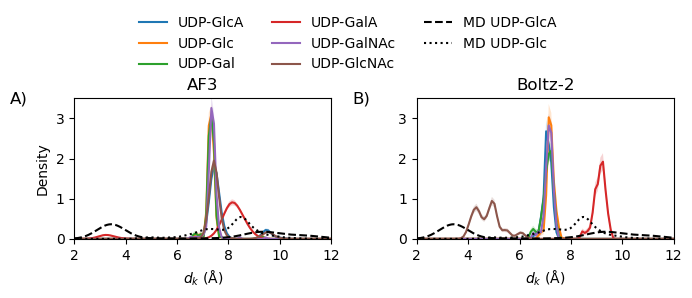

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].set_title("AF3")
axes[1].set_title("Boltz-2")

plot_bootstrap_kde(axes[0], datasets_kde_af3, ylim=(-0.01,3.5))
plot_bootstrap_kde(axes[1], datasets_kde_boltz, ylim=(-0.01,3.5))


# Panel labels
panel_letter(axes[0], "A")
panel_letter(axes[1], "B")


# Remove right y-labels for cleaner layout
axes[1].set_ylabel("")
#axes[1,1].set_ylabel("")

# Global legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center",
           bbox_to_anchor=(0.5, 1.),   # più alto
           ncol=3,
           frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.8])

plt.savefig("Figure_af3_boltz.png", dpi=600, bbox_inches="tight")


plt.show()